## 评估文本生成模型
### 使用GPT生成文本

In [11]:
import sys
import os
# 获取当前文件的目录
root_dir = os.path.dirname(os.path.abspath("."))  # "." 就是当前 notebook 的运行目录
# 把根目录加入 sys.path
sys.path.append(root_dir)
# print(root_dir)
from ch04.GPTModel import GPTModel
import torch

GPT_CONFIG_124M = {
    "vocab_size": 50257,    # 总词汇表大小，即一共有多少个单词
    "context_length": 256, # 上下文窗口长度，即将vocab_size进行切分后，每组的大小
    "emb_dim": 768,         # 词元 embeding 维度，将单个词嵌入后的维度大小
    "n_heads": 12,          # 注意力头数量
    "n_layers": 12,         # 网络层数
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MutilHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MutilHeadAttention(
        (W_query): Linear(in_features

In [19]:
import tiktoken
from ch04.GPTModel import generate_text_simple
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    # 添加batch维度
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) 
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    # 移除batch维度
    flat = token_ids.squeeze(0) 
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_length=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))


Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


### 计算文本生成损失

![textGenPipeline](imgs/textGenPipeline.png)

上图展示了从输入文本到大语言模型生成文本的整体流程。对于左侧显示的3个输入词元中的每一个，计算包含词汇表中每个词元对应概率分数的向量。每个向量中最高概率分数的索引位置表示最有可能的下一个词元ID。这些与最高概率分数相关联的词元ID会被选中并映射回表示模型生成的文本

接下来我们先模拟一下损失计算过程

In [3]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

inputs是我们输入给模型的示例词元id，targets是我们希望模型生成的词元ID，其中targets是对输入数据的复制，但向前移动了一个位置

现在，将这些输入提供给模型，为包含3个词元的两个输入示例计算logits向量。然后，应用softmax函数将这些logits转换为概率分数

In [4]:
with torch.no_grad():
    logits = model(inputs)
print(logits.shape)
probas = torch.softmax(logits, dim=-1) 
print(probas.shape) # Shape: (batch_size, num_tokens, vocab_size)

torch.Size([2, 3, 50257])
torch.Size([2, 3, 50257])


第一个数值2对应于输入中的两个示例（行）​，也称为“批次大小”​。第二个数值3对应于每个输入（行）中的词元数量。最后一个数值50257对应于嵌入维度，由词汇表大小确定。通过softmax函数将logits转换为概率后，generate_text_simple函数会将结果概率分数转换回文本​。可以通过将argmax函数应用于概率分数来完成第3步和第4步，从而获得相应的词元ID

In [5]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


最后，将词元ID转换回文本

In [6]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


模型生成的随机文本与目标文本不同的原因是它尚未经过训练。现在，我们希望通过损失指标来量化评估模型生成的文本的性能。这不仅有助于衡量生成的文本的质量，同时也是实现训练函数的一个构建块，我们将使用它来更新模型的权重，从而改善生成的文本。

文本评估过程的一部分是衡量生成词元与正确预测（目标）之间的偏差程度。我们稍后实现的训练函数将使用这些信息来调整模型权重，以生成更接近（或理想情况下更匹配）目标文本的文本

模型训练的目标是增大与正确目标词元ID对应的索引位置的softmax概率。这个softmax概率也将用于我们接下来要实现的评估指标中，以量化评估模型生成的输出：正确位置的概率越高，效果越好

![textGenPipeline](imgs/textGenPipeline.png)

在训练之前，模型会生成随机的下一个词元的概率向量。模型训练的目标是确保与图中框出的目标词元ID对应的概率值被最大化

In [7]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


上述代码输出了模型输出的目标词元对应的初始softmax概率分数

这只是模型的第一次迭代输出，我们最终的目标是想让这些概率值等无限接近于1，为此我们需要构造一个损失函数来进行最优迭代，这个最优迭代的过程就是训练的过程，在神经网络中我们称这一过程为反向传播

### 反向传播
如何最大化与目标词元对应的softmax概率值呢？大致思路是，更新模型权重，以便模型为我们想要生成的相应词元ID输出更高的值。权重更新是通过一种称为反向传播的过程完成的

反向传播需要一个损失函数，它会计算模型的预测输出（在这里是与目标词元ID对应的概率）与实际期望输出之间的差异。这个损失函数衡量的是模型的预测与目标值之间的偏差。

接下来，我们将计算两个示例批次的概率分数的损失，即target_probas_1和target_probas_2。

In [8]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


再次强调，上述概率值是正确词元ID的概率值，我们的目标是希望上述概率值经过反向传播后都变成1

为了衡量上述误差，我们借助数学工具对数函数，因为log(1)等于0，所以如果我们把概率值都取对数之后，我们的训练目标就变成了如何更新权重，使得log_probas变成0

现在我们已经转换了训练目标（让所有的log_probas都变成0），进一步的，我们的目标还可以转换成log_probas的平均值为0，因此接下来，我们通过计算平均值将这些对数概率组合成一个单一分数

In [9]:
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


最终我们的目标变成了：通过在训练过程中更新模型的权重，使平均对数概率尽可能接近0。

然而，由于概率值的取值范围为(0,1]，因此log_probas≤0,而在深度学习中，所使用的优化器目标都是最小损失，因此最终要对avg_log_probas取负，让avg_log_probas变成正数，这样符合优化器的训练

In [10]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


在深度学习中，将-10.7940这个负值转换为10.7940的术语称为交叉熵损失。PyTorch在这里派上了用场，因为它有一个内置的cross_entropy函数

交叉熵损失是一种常用的度量方式，用于衡量两个概率分布之间的差异

In [11]:
# Logits have shape (batch_size, num_tokens, vocab_size)
print("Logits shape:", logits.shape)

# Targets have shape (batch_size, num_tokens)
print("Targets shape:", targets.shape)


"""
F.cross_entropy 要求输入是 (N, C) 和 (N,) 的形状，其中：
N = 样本总数（这里是 2×3=6 个独立的预测位置）
C = 类别数（50257 个词）
把 (2, 3) 的序列维度展平，本质上是把每个 token 位置的预测都当作一个独立的分类问题。
"""
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])
Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


targets是我们希望大语言模型生成的词元ID，而logits是在进入softmax函数以获取概率分数之前的未经缩放的模型输出。

先前，我们应用softmax函数，选择了与目标ID对应的概率分数，并计算了负对数概率的平均值。PyTorch的cross_entropy函数将为我们处理所有这些步骤

In [12]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


### 计算训练集和验证集的损失

本节的主要工作是准备用于训练大语言模型的训练数据集和验证数据集，并计算训练集和验证集的交叉熵

In [13]:
with open("the-verdict.txt","r") as f:
    text_data=f.read()

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [14]:
from ch02.DateSet import create_dataloader_v1

# 将文本的90%内容作为训练集，剩余的10%内容构建成验证集
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

# 测试检查数据集是否创建成功
if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


如上输出，我们有9个训练集批次，其中每个批次包含两个样本，每个样本包含256个词元。

由于我们仅将10%的数据用于验证，因此只有一个包含两个输入示例的验证批次。正如预期的那样，输入数据(x)和目标数据(y)具有相同的形状（批次大小×每个批次中的词元数）​，因为targets是将输入向后移动一个位置得到的

接下来，我们实现一个工具函数，用于计算通过训练集加载器和验证集加载器返回的给定批次的交叉熵损失

In [15]:
# 计算单批次损失
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

In [16]:
# 计算所有批次的损失
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

calc_loss_loader函数会遍历给定数据加载器中的所有批次，将损失累积在total_loss变量中，然后计算所有批次的损失的平均值。或者，可以通过num_batches指定较小的批次数，以加快模型训练期间的评估速度

In [17]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")


print(f"Using {device} device.")

model.to(device) 

torch.manual_seed(123) 

with torch.no_grad(): 
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Using cpu device.
Training loss: 10.98758347829183
Validation loss: 10.98110580444336


由于模型尚未经过训练，因此损失值相对较高。相比之下，如果模型学会按照训练集和验证集中词元的出现顺序生成下一个词元，那么损失将接近于0

现在我们有了一种衡量生成文本质量的方法，我们将训练大语言模型以减少这种损失，使其在生成文本方面变得更好

## 训练大语言模型

In [18]:
# 模型训练
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # 初始化列表，记录损失
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # epoch迭代
    for epoch in range(num_epochs):
        model.train()  
        
        for input_batch, target_batch in train_loader:
            # 重置上一个批次迭代中的损失梯度
            optimizer.zero_grad() 
            # 计算损失
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            # 计算损失梯度
            loss.backward()
            # 使用损失梯度更新模型权重 
            optimizer.step() 
            tokens_seen += input_batch.numel()
            global_step += 1

            # 可选的评估步骤
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # 每轮之后打印一个文本样本
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_length=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

evaluate_model函数会在每次模型更新后打印训练集和验证集的损失，以便我们可以评估训练是否改善了模型性能。具体而言，evaluate_model函数在计算训练集和验证集的损失时会确保模型处于评估模式，同时会禁用梯度跟踪和Dropout

generate_and_print_sample函数可以用来跟踪模型在训练过程中是否有所改进。具体而言，generate_and_print_sample函数以文本片段(start_context)作为输入，先将其转换为词元ID，然后将其提供给大语言模型，最后使用我们之前使用的generate_text_simple函数生成一个文本样本

Adam优化器是训练深度神经网络的一种常见选择。然而，我们的训练循环中选择了AdamW优化器。AdamW是Adam的一个变体，它改进了权重衰减方法，旨在通过对较大的权重进行惩罚来最小化模型复杂性并防止过拟合。

这种调整使得AdamW能够实现更有效的正则化和更好的泛化能力。因此，在大语言模型的训练中经常使用AdamW。我们通过使用之前定义的AdamW优化器和train_model_simple函数，对一个GPTModel实例进行10轮的训练，来看看这一切是如何运作的

In [19]:
import time
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
# 定义优化器
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
# optimizer = torch.optim.SGD(model.parameters(), lr=5e-3)

# 设置迭代轮数
num_epochs = 10
# 开始训练
start_time=time.time()
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.781, Val loss 9.933
Ep 1 (Step 000005): Train loss 8.111, Val loss 8.339
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.661, Val loss 7.048
Ep 2 (Step 000015): Train loss 5.961, Val loss 6.616
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Ep 3 (Step 000020): Train loss 5.726, Val loss 6.600
Ep 3 (Step 000025): Train loss 5.201, Val loss 6.348
Every effort moves you, and I had been.                                            
Ep 4 (Step 000030): Train loss 4.417, Val loss 6.278
Ep 4 (Step 000035): Train loss 4.069, Val loss 6.226
Every effort moves you know the                          "I he had the donkey and I had the and I had the donkey and down the room, I had
Ep 5 (Step 000040): Train loss 3.732, Val loss 6.160
Every effort moves you know it was not that the picture--I had the fact by the last

如你所见，训练集损失有了显著的改善，从9.781的初始值收敛到了0.391。模型的语言能力得到了相当大的提升。在开始阶段，模型只能在起始上下文后添加逗号(Every effort moves you,,,,,,,,,,,,)或重复单词and。在训练结束时，它已经可以生成语法正确的文本。

与训练集损失类似，验证集损失在训练过程中从较高值(9.933)开始逐渐降低。然而，它永远不会像训练集损失那样变得很小，在第10轮之后其值为6.452。

接下来我们创建一张简单的图表，将训练集和验证集的损失并列显示

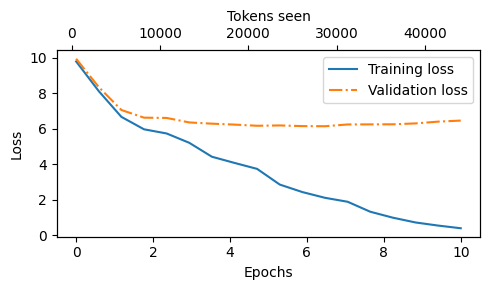

In [20]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## 控制随机性的解码策略

In [22]:
inference_device="cpu"
model.to(inference_device)
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=25,
    context_length=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know," was one of the axioms he laid down across the Sevres and silver of an exquisitely appointed lun


如上所述，我们使用训练好的模型重新生成文本，在每个生成步骤中，生成的词元是从词汇表的所有词元中选择概率分数最大的那一个。

这意味着，即使在相同的起始上下文(Every effort moves you)中多次运行前面的generate_text_simple函数，大语言模型也将始终生成相同的输出。

### 温度缩放

温度缩放是一种在下一个词元生成任务中添加概率选择过程的技术。

在之前的generate_text_simple函数中，我们总是使用torch.argmax（也称为贪婪解码）来采样具有最高概率的词元作为下一个词元。为了生成更多样化的文本，可以用一个从概率分布（这里是大语言模型在每个词元生成步骤为每个词汇条目生成的概率分数）中采样的函数来取代argmax。

为了用一个具体的例子来说明概率采样，让我们使用一张非常小的词汇表来简要讨论下一个词元生成过程

In [23]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}

# 假设大语言模型被赋予的起始上下文为"every effort moves you"，并生成了以下下一个词元的logits
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

# 在generate_text_simple中，我们通过softmax函数将logits转换为概率
# 并通过argmax函数获取与生成的词元对应的词元ID，然后通过反向词汇表将其映射回文本
probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()

print(inverse_vocab[next_token_id])

forward


由于最大的logits值和相对应的最大的softmax概率分数在第四个位置（因为Python使用0索引作为初始索引，所以索引位置为3）​，因此生成的单词是forward。

为了实现一个概率采样过程，现在可以用PyTorch中的multinomial函数替换argmax

In [24]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


打印输出仍然是forward。原理是什么呢？multinomial函数按照其概率分数采样下一个词元。换句话说，forward仍然是最可能的词元，大多数时间（但不是每次）都会被multinomial选中。为了说明这一点，让我们实现一个将此采样重复1000次的函数

In [25]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


你所见，单词forward大多数时候会被采样（1000次中有582次）​，但其他词元（如closer、inches和toward）有时也会被采样。这意味着，如果在generate_and_print_sample函数中用multinomial函数替换argmax函数，那么大语言模型有时会生成诸如every effort moves you toward、every effort moves you inches和every effort moves you closer之类的文本，而不是every effort moves you forward。

通过一个称为温度缩放的概念，可以进一步控制分布和选择过程。温度缩放指的是将logits除以一个大于0的数

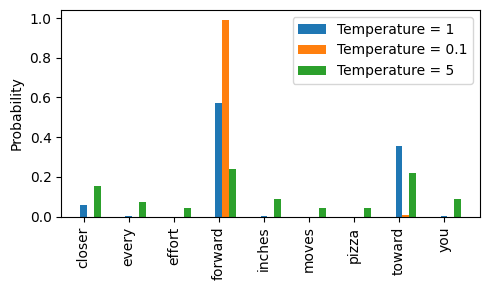

In [27]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# 温度值
temperatures = [1, 0.1, 5]  

# 计算缩放后的概率值
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

温度大于1会导致词元概率更加均匀分布，而小于1的温度将导致更加自信（更尖锐或更陡峭）的分布。

在scaled_logits = logits / temperature中，
将所有 logits 都除以了同一个温度值 T。如果后续的操作是线性的，那么最终的相对比例确实不会改变。
但关键在于，这个除法操作是在 Softmax 函数之前进行的，而 Softmax 函数本身是一个指数级（非线性）的转换。正是这个非线性特性，导致了即使对 logits 进行了统一的线性缩放，最终的概率分布也会发生显著变化。

核心原因在于，除以 T 改变了 logits 之间的差值被指数函数放大的程度。

示例：三种温度下的分布变化
假设我们有三个类别的 logits：z = [3, 1, 0.5]。
情况 1：标准 Softmax (T = 1)
 * Scaled Logits: [3, 1, 0.5] (不变)
 * Exponentiated: [e^3, e^1, e^0.5] ≈ [20.09, 2.72, 1.65]
 * Sum: 20.09 + 2.72 + 1.65 = 24.46
 * Probabilities: [20.09/24.46, 2.72/24.46, 1.65/24.46] ≈ [0.821, 0.111, 0.067]
这是一个比较“尖锐”（peaked）的分布，模型对第一个类别非常有信心。
情况 2：高温度 (T = 2，软化分布)
 * Scaled Logits: [3/2, 1/2, 0.5/2] = [1.5, 0.5, 0.25]
 * Exponentiated: [e^1.5, e^0.5, e^0.25] ≈ [4.48, 1.65, 1.28]
 * Sum: 4.48 + 1.65 + 1.28 = 7.41
 * Probabilities: [4.48/7.41, 1.65/7.41, 1.28/7.41] ≈ [0.605, 0.223, 0.173]
观察：
 * 所有 logits 都变小了，并且它们之间的绝对差值也变小了（例如，3-1=2 变成了 1.5-0.5=1）。
 * 由于指数函数对较小的差值不那么敏感，原始 logits 之间的“优势”被削弱了。
 * 最终的概率分布变得更加平滑和均匀。模型的“信心”下降了，它现在认为其他类别也有一定的可能性。
情况 3：低温度 (T = 0.5，锐化分布)
 * Scaled Logits: [3/0.5, 1/0.5, 0.5/0.5] = [6, 2, 1]
 * Exponentiated: [e^6, e^2, e^1] ≈ [403.4, 7.39, 2.72]
 * Sum: 403.4 + 7.39 + 2.72 = 413.51
 * Probabilities: [403.4/413.51, 7.39/413.51, 2.72/413.51] ≈ [0.975, 0.018, 0.007]
观察：
 * 所有 logits 都变大了，并且它们之间的绝对差值也变大了（例如，3-1=2 变成了 6-2=4）。
 * 指数函数极大地放大了这个更大的差距。
 * 最终的概率分布变得更加尖锐，几乎变成了一个 one-hot 分布。模型变得极端自信（或者说“固执”），几乎完全排除了其他选项。

总结
 * 为什么分布会变？ 因为对 logits 的除法操作，改变了输入到指数函数中的 logits 之间的差值。
 * T > 1 (升温)：会缩小 logits 之间的差距，使得 Softmax 的输出概率分布更平滑、更不确定（熵更高）。这在需要增加生成文本多样性时很有用。
 * T < 1 (降温)：会扩大 logits 之间的差距，使得 Softmax 的输出概率分布更尖锐、更确定（熵更低）。这在希望模型选择最可能的输出时很有用。
 * T = 1：标准的 Softmax 行为。

### Top-K采样

我们现在已经实现了一种结合温度缩放的概率采样方法，以此来增加输出结果的多样性。我们发现，较高的温度值会导致下一个词元的概率分布更均匀，从而产生更多样化的输出，因为它降低了模型重复选择最可能词元的可能性。这种方法允许探索概率较低但可能更具创造性和趣味性的生成路径。然而，这种方法的一个缺点是，它有时会导致语法不正确或完全无意义的输出，比如every effort moves you pizza

通过与概率采样和温度缩放相结合，Top-k采样可以改善文本生成结果。在top-k采样中，可以将采样的词元限制在前k个最可能的词元上，并通过掩码概率分数的方式来排除其他词元，如图所示

![topkScale](imgs/topkScale.png)

top-k采样方法用负无穷值(-inf)替换所有未选择的logits，因此在计算softmax值时，非前k词元的概率分数为0，剩余的概率总和为1

首先，从选择logits值最高的前3个词元开始

In [28]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)

print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


随后，使用PyTorch的where函数将低于我们选择的前3个词元中最低logits值的词元的logits值设置为负无穷(-inf)

In [29]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")), 
    other=next_token_logits
)

print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


最后，应用softmax函数将这些值转换为下一个词元的概率

In [30]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### 修改文本生成函数

现在，让我们结合温度放缩和top-k采样修改之前用于通过大语言模型生成文本的generate_text_simple函数，从而创建一个新的generate函数

In [17]:
"""
model:语言模型（如 GPT），输入 token IDs 输出 logits
idx:已生成的 token 序列，形状 (batch_size, num_tokens)
max_new_tokens:最多生成多少个新 token
context_size:模型能处理的最大上下文长度（滑动窗口）
temperature:温度参数，控制生成随机性（0=贪婪解码）
top_k:Top-K 采样，只从概率最高的 K 个 token 中选
eos_id:序列结束标记（End of Sequence），遇到则停止
"""
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    # 每次循环生成 1 个新 token，直到达到 max_new_tokens 上限或遇到 eos_id
    for _ in range(max_new_tokens):
        # 只保留序列的最后 context_size 个 token 作为模型输入
        idx_cond = idx[:, -context_size:]
        # 模型预测
        with torch.no_grad():
            logits = model(idx_cond)
        # 语言模型是对每个输入位置都输出预测，但最后一个位置的下一个 token 预测才是我们想要的
        logits = logits[:, -1, :]

        # 执行top-k策略，避免选择概率极低的"离谱" token，提高生成质量
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # 温度缩放策略
        if temperature > 0.0:
            # # 温度缩放
            logits = logits / temperature
            # 数值稳定性处理
            """
            直接计算 e^x_j时，如果 logits 的值很大（比如几百），指数会爆炸性增长，导致：
                上溢（Overflow）：exp(1000) → inf
                下溢（Underflow）：分母变成 inf，结果变成 nan
            然而softmax 有一个重要性质：所有元素同时减去同一个常数，结果不变
            所以让logits 的每一行都减去该行的最大值，就能让所有指数运算都在可控范围内
            """
            logits = logits - logits.max(dim=-1, keepdim=True).values
            # # 转概率分布
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)
            #  # 按概率采样
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)
        # 正常计算概率值，贪婪解码，直接选概率最高的 token，完全确定性输出
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)
        # 如果遇到序列结束词元，则提前停止生成
        if idx_next == eos_id: 
            break
        # 将新生成的 token 拼接到序列末尾
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [34]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you stand to work on surprise, a one of us had gone with random-


如你所见，通过新的generate函数生成的文本与通过本节开头的generate_text_simple函数生成的文本("Every effort moves you know," was one of the axioms he laid...)截然不同，后者是训练集中被记住的一个段落

## 加载和保存模型权重

保存PyTorch模型相对比较简单。推荐使用torch.save函数保存模型的state_dict，即将每个层映射到其参数的字典

model.pth是保存state_dict的文件名。.pth扩展名是PyTorch文件的规范，尽管从技术上讲可以使用任何文件扩展名。

In [35]:
torch.save(model.state_dict(), "model.pth")

在通过state_dict保存模型权重之后，可以将模型权重加载到一个新的GPTModel模型实例中

In [36]:
model = GPTModel(GPT_CONFIG_124M)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
model.eval()

Device: cpu


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MutilHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MutilHeadAttention(
        (W_query): Linear(in_features

dropout通过在训练过程中随机“丢弃”一层的神经元，有助于防止模型对训练数据过拟合。然而，在推断过程中，我们不希望随机丢弃网络学习到的任何信息。因此，可以使用model.eval()将模型切换到推断模式，这样就会禁用模型的dropout层。如果计划稍后继续预训练模型，可以使用本章前面定义的train_model_simple函数，建议同时保存优化器状态。

像AdamW这样的自适应优化器可以为每个模型权重存储额外的参数。AdamW可以使用历史数据动态地调整每个模型参数的学习率。如果没有它，那么优化器就会重置，模型可能学习效果不佳，甚至无法正确收敛，这意味着模型将失去生成连贯文本的能力。可以使用torch.save保存模型和优化器的state_dict内容

In [37]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    }, 
    "model_and_optimizer.pth"
)

然后，可以先使用torch.load加载保存的数据，再使用load_state_dict方法来恢复模型和优化器的状态

In [ ]:
checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train()

## 从OpenAI加载预训练权重

OpenAI公开分享了它们的GPT-2模型的权重，因此，我们可以将这些权重加载到GPTModel类中，并使用该模型进行文本生成。这里，权重指的是存储在PyTorch的Linear层和Embedding层的.weight属性中的权重参数。前面在训练模型时，我们通过model.parameters()访问过它们。

在后边我们将重用这些预训练权重来对模型进行微调，以完成文本分类任务，并按照类似ChatGPT的指令进行操作

需要注意的是，OpenAI最初通过TensorFlow保存了GPT-2的权重，我们需要在Python中安装TensorFlow才能加载这些权重。下面的代码将使用一个名为tqdm的进度条工具来跟踪下载过程，我们也需要安装这个工具。

pip install tensorflow tqdm

In [2]:
from importlib.metadata import version
print("TensorFlow version:", version("tensorflow"))
print("tqdm version:", version("tqdm"))

TensorFlow version: 2.21.0
tqdm version: 4.67.3


In [5]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")


I0000 00:00:1778406739.728377    5541 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 145kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:02<00:00, 496kiB/s] 
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 130kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [20:31<00:00, 404kiB/s]    
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 2.79MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:01<00:00, 328kiB/s]  
vocab.bpe: 100%|██████████| 456k/456k [00:01<00:00, 244kiB/s]  


Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}


W0000 00:00:1778407988.450096    5541 cpu_allocator_impl.cc:82] Allocation of 154389504 exceeds 10% of free system memory.


settings和params都是Python字典。settings字典存储了大语言模型架构的设置，类似于我们手动定义的GPT_CONFIG_124M。params字典包含实际的权重张量。

In [7]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())
# token嵌入层权重
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])
[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


将GPT-2模型的权重加载到Python后，仍然需要将它们从settings字典和params字典转移到我们的GPTModel实例中。首先，创建一个字典，使用model_configs表中对应的设置来更新我们之前定义并使用的完整长度的GPT_CONFIG_124M,我们之前使用了256个词元长度，但OpenAI的原始GPT-2模型是使用1024个词元长度进行训练的，因此需要相应地更新NEW_CONFIG

另外，OpenAI在多头注意力模块的线性层中使用了偏置向量来实现查询矩阵、键矩阵和值矩阵的计算。偏置向量在当前的大语言模型中不常用，因为它们并不提升建模性能，因此不是必要的。然而，由于我们正在使用预训练权重，因此需要匹配相应的设置以保持一致性，并启用这些偏置向量

In [12]:
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

print(GPT_CONFIG_124M)
model_name = "gpt2-small (124M)"  
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})
print(NEW_CONFIG)

# 使用更新后的配置初始化一个新的GPTModel实例
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

{'vocab_size': 50257, 'context_length': 256, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': False}
{'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': True}


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MutilHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MutilHeadAttention(
        (W_query): Linear(in_features=7

GPTModel实例使用随机权重初始化以进行预训练。使用OpenAI的模型权重的最后一步是用加载到params字典中的权重覆盖这些随机权重。

In [13]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [15]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])
    
device="cpu"
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MutilHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MutilHeadAttention(
        (W_query): Linear(in_features=7

如果模型成功加载，那么现在可以使用之前的generate函数来生成新文本

In [20]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward finding an ideal new way to practice something!

What makes us want to be on top of that?


